In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = { s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = { i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3  # context length: how many characters do we take to predict the next one?
X, Y = [], []    # X is inputs to the neural net and Y is the labels to each example inside it
for w in words:

    # print(w)
    context = [0] * block_size    # creates [0, 0, 0] for block_size 3, (padded context)
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context [1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
# Mapping our 27 character space to 2D space with this LUT
C = torch.randn((27, 2))
# We are talking in terms of row-vectors, that is why this transformation matrix is 27*2 and not 2*27

In [8]:
C[5]

tensor([-0.3121, -1.6920])

In [9]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C        # One hot encodes only torch tensors

tensor([-0.3121, -1.6920])

In [10]:
# If we take this one hot vector (it is a row vector) and multiply it by C then we just get where vector lands after the transofrmation
# But because we are using one hot vector (orthonormal unit basis), this just happens to be the transformed version of the 5th symbol
# Thus rather than using the vector @ C, we can directly use C[x]

# Also the default dtype of the one_hot function is int64 and C is float32, torch cant multiply float32 and int32 that is why we have to explicitly cast the function to float

In [11]:
# We will be considering this C layer as our first neuron layer with C as the weights

In [12]:
C[torch.tensor([5,6,7,7,7,7])], C[[5,6,7]]

(tensor([[-0.3121, -1.6920],
         [-2.8563,  0.0486],
         [ 0.6917,  0.6504],
         [ 0.6917,  0.6504],
         [ 0.6917,  0.6504],
         [ 0.6917,  0.6504]]),
 tensor([[-0.3121, -1.6920],
         [-2.8563,  0.0486],
         [ 0.6917,  0.6504]]))

In [13]:
C[X].shape
# Wait 1D vector inside index makes sense but 2D??? Here is what's happening

# # --------- EXAMPLE -----------
# C = torch.tensor([
#     [10, 11],
#     [20, 21],
#     [30, 31],
#     [40, 41],
# ])  # shape (4, 2)

# X = torch.tensor([
#     [0, 3],
#     [1, 2],
# ])  # shape (2, 2)

# Noe evaluate C[X]:
# Manually:
# X[0,0] = 0 → C[0] = [10, 11]
# X[0,1] = 3 → C[3] = [40, 41]
# X[1,0] = 1 → C[1] = [20, 21]
# X[1,1] = 2 → C[2] = [30, 31]

# So the output is:
# [
#   [[10, 11], [40, 41]],
#   [[20, 21], [30, 31]],
# ]

# Shape: (2,2,2)
# ------------------------------------

torch.Size([228146, 3, 2])

In [14]:
X[13, 2]

tensor(1)

In [15]:
C[X][13, 2]

tensor([-1.2820, -0.0121])

In [16]:
C[1]

tensor([-1.2820, -0.0121])

In [17]:
C = torch.randn((27, 2))

In [18]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [19]:
# Now we are making the next neuron layer in our MLP
W1 = torch.randn((6, 100))     # Size (6, 100) because we are taking 100 neruons in this layer and there are 6 inputs to each one (3chars*2D embedding)
b1 = torch.randn(100)      # 100 biases for 100 neurons

In [20]:
# Normally we would do emb@W1 + b1 for the output of the layer but emb@W1 would not be possible right now because of the shape of emb
# To sort this we concatenate emb, i.e., for the 3 consecutive values that are together, we will concatenate them
# To do this we use torch.cat function
# there is a literal sea of functions in torch so if you need anything just seach for what you want in the doc (or just ask gpt)

torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape         # 1 is the dimension along which we want to concatenate

torch.Size([228146, 6])

In [21]:
# The above code is ugly because it wont generalise to any number of blocks (we used 3 and that was for three only)
# To sort this torch has another thing called unbind
# torch.unbind(input, dim=0) → seq
# Removes a tensor dimension.
# Returns a tuple of all slices along a given dimension, already without it.
print('='*5, 'torch.unbind', '='*5)
# Example
print(torch.unbind(torch.tensor([[1, 2, 3],
                           [4, 5, 6],
                           [7, 8, 9]])))      # Runs for default dim (0)
print(torch.unbind(torch.tensor([[1, 2, 3],
                           [4, 5, 6],
                           [7, 8, 9]]), 1))     # dim= 1

print('='*5, 'torch.cat', '='*5)

#--------- EXAMPLE for torch.cat-------
x = torch.tensor([[1, 2, 3],
                           [4, 5, 6],
                           [7, 8, 9]])
print(x)
print(torch.cat((x, x, x), 0), torch.cat((x, x, x), 0).shape)
print(torch.cat((x, x, x), 1), torch.cat((x, x, x), 1).shape)

===== torch.unbind =====
(tensor([1, 2, 3]), tensor([4, 5, 6]), tensor([7, 8, 9]))
(tensor([1, 4, 7]), tensor([2, 5, 8]), tensor([3, 6, 9]))
===== torch.cat =====
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]) torch.Size([9, 3])
tensor([[1, 2, 3, 1, 2, 3, 1, 2, 3],
        [4, 5, 6, 4, 5, 6, 4, 5, 6],
        [7, 8, 9, 7, 8, 9, 7, 8, 9]]) torch.Size([3, 9])


In [22]:
# So better concatenation code would be
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([228146, 6])

In [23]:
# Another cool thing of PyTorch
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [24]:
a.view(3,3,2)      # This can be used to change the dimension as long as dimensions multiply to give the same number    

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [25]:
# The view thing works because a tensor is always stored as a 1D vector in memory
# When we call .view, only some of the internal attributes of the tensor change which are responsible for how we see the tensor

a.storage() 

C:\Users\tusha\AppData\Local\Temp\ipykernel_38584\1793978019.py:4: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [26]:
# So from here we get another thing to use in place of concatenation
# emb.view happens to merge the dimensions 1 and 2, which is what we wanted
emb.view(32, 6)

# We can check if they are equal 
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [27]:
# Concatention is also inefficient because new storage is being created

# Actual emb@W+b
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)         # -1 in the input tells pytorch to calculate the dimension by itself, this is good for generalization because then any number of embeddings can be passed though with the same code
h
# When we are adding b1, broadcasting is also happening
# W1 (32, 100)
# b1      100  --> broadcasting makes it (1, 100) and then makes vertical copies to add

tensor([[ 0.0567, -0.9214,  0.6415,  ...,  0.0271,  0.2488, -0.5270],
        [ 0.1045, -0.9543,  0.9946,  ..., -0.9481,  0.3228, -0.9865],
        [ 0.9998,  0.9459,  0.6825,  ..., -0.3289, -0.0720, -0.9944],
        ...,
        [ 0.9736, -0.9709,  0.6657,  ...,  0.4106, -0.3688,  0.2690],
        [ 0.9831, -0.8198, -0.5416,  ...,  0.6568, -0.6645, -0.5032],
        [ 0.9765, -0.9348,  0.4308,  ...,  0.6919,  0.2881,  0.5811]])

In [28]:
# Next and final layer of neurons
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [29]:
logits = h @ W2 + b2

In [30]:
logits.shape

torch.Size([228146, 27])

In [31]:
counts = logits.exp()

In [32]:
prob = counts / counts.sum(1, keepdim=True)

In [33]:
prob.shape

torch.Size([228146, 27])

In [34]:
prob[0].sum()      # Gives one means it is normalised

tensor(1.0000)

In [35]:
Y        #  Y is the actual letter in the sequence that we want to predict

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [36]:
torch.arange(32)        # iterator over numbers from o to 31 for each row

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [39]:
loss = -prob[torch.arange(32), Y].log().mean()
loss
# prob[torch.arange(32), Y] means
# [
#   prob[0, Y[0]],
#   prob[1, Y[1]],
#   prob[2, Y[2]],
#   ...
#   prob[31, Y[31]]
# ]


IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [40]:
# --------------- now made respectable :) --------------

In [41]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [42]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 100), generator=g)
b2 = torch.randn(100, generator=g)
W3 = torch.randn((100, 27), generator=g)
b3 = torch.randn(27, generator=g)

In [43]:
lri = []
lrei = []
lossi = []
stepi = []

In [44]:
device = 'cuda'

C = C.to(device)
W1 = W1.to(device)
b1 = b1.to(device)
W2 = W2.to(device)
b2 = b2.to(device)
W3 = W3.to(device)
b3 = b3.to(device)

Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xdev = Xdev.to(device)
Ydev = Ydev.to(device)
Xte = Xte.to(device)
Yte = Yte.to(device)

parameters = [C, W1, b1, W2, b2, W3, b3]


for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters) # number of parameters in total

batch_size = 4096  # try 256 or 512

In [45]:

for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device = device)
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h1 = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
    logits = h2 @ W3 + b3 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
   
    # backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    # update
    for p in parameters: 
        p.data += -lr * p.grad


    # track stats
    # lri.append(lr)
    # lrei.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)

# Now if we work on the full dataset of over 200k entries then that will take a lot of time (really lot)
# So to address that, people usually train the model on mini-batches (A random part of the complete batch)
# With the mini-batch, we can run much more optimization loops and hence get lower loss but the quality of model i

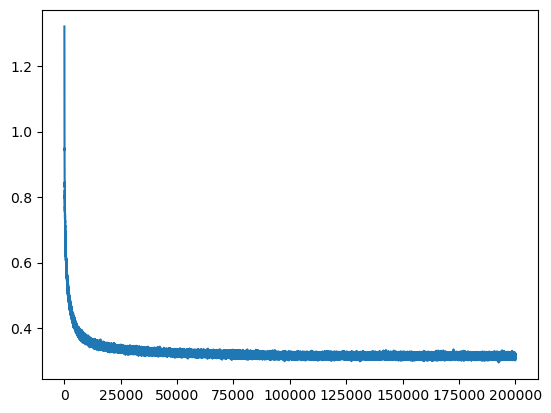

In [46]:
plt.plot(stepi, lossi)
# The noise is due to small batch size and can be reduced by increasing it

In [47]:
emb = C[Xtr] # (32, 3, 2)
h1 = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
logits = h2 @ W3 + b3 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0617, device='cuda:0', grad_fn=<NllLossBackward0>)

In [48]:

emb = C[Xdev] # (32, 3, 2)
h1 = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
logits = h2 @ W3 + b3 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1631, device='cuda:0', grad_fn=<NllLossBackward0>)

In [ ]:
emb = C[Xte] # (32, 3, 2)
h1 = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
logits = h2 @ W3 + b3 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

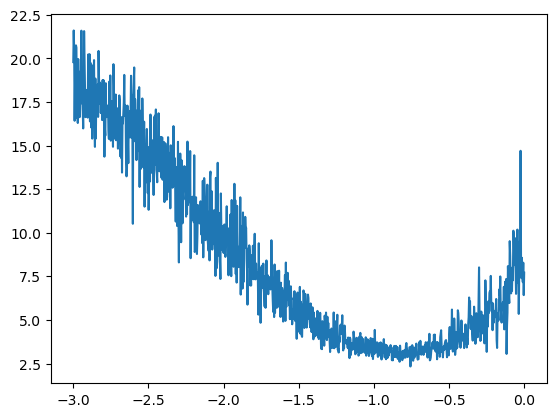

In [117]:
plt.plot(lrei, lossi)

In [131]:
# We can see in the curve that good learning rate is around lre = -1 or lr = 0.1 

In [132]:
# As the capacity of the neural network grows, it becomes more and more capable of overfitting the trainging set.
# Too less loss means that the model might have just 'memorised' the data, it will just output stuff from datast and no new thing

In [133]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# Training set is used to optimise the parameters of the model, as we know the weights and biases etc
# dev set is to optimise the hyperparameters of the model, size of the hidden layer, size of embedding, strength of regularization etc which are not optimised in training
# test split is used to evaluate the model, only allowed to see loss on it only few times to avoid overfitting model on this

In [146]:
# If training loss and dev loss are almost equal then it typically means that we are underfitting and expect to make improvements by increasing the size of the network

In [51]:
# sample from the model

for _ in range(15):

    out = []

    # context as a CUDA tensor
    context = torch.zeros((1, block_size), dtype=torch.long, device=device)

    while True:
        # embedding lookup
        emb = C[context]                      # (1, block_size, d)
        h1 = torch.tanh(emb.view(1, -1) @ W1 + b1)
        h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
        logits = h2 @ W3 + b3
        probs = F.softmax(logits, dim=1)

        # sample next token (already on GPU)
        ix = torch.multinomial(probs, num_samples=1)


        # update context (shift left, append ix)
        context = torch.cat([context[:, 1:], ix], dim=1)

        out.append(ix.item())  # only convert to Python here

        if ix.item() == 0:
            break

    print(''.join(itos[i] for i in out))


caitanai.
desie.
ephanco.
hol.
xaeelanderd.
oslahnoynity.
kyo.
decindo.
laenyzel.
rosen.
ana.
keiah.
caydenision.
charicky.
tawkinn.
